# Exploratory Data Analysis — LSST Dataset

The **LSST** (Legacy Survey of Space and Time) dataset contains multivariate time series
of astronomical transient light curves across 6 photometric bands.

- **Source**: UCR/UEA multivariate time series archive
- **Task**: Classify transients into 14 classes
- **Shape**: (n_samples, 36 timesteps, 6 channels)
- **Train/Test split**: 2 459 / 2 466 samples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data_loader import load_lsst_raw, to_channels_first, SEED

sns.set_theme(style="whitegrid", font_scale=1.1)
BAND_NAMES = ["u", "g", "r", "i", "z", "y"]  # LSST photometric bands

X_train_raw, y_train, X_test_raw, y_test = load_lsst_raw()
# tslearn format: (n, T, C) — keep for plotting, also make channels-first
X_train_cf = to_channels_first(X_train_raw).astype(np.float32)  # (n, C, T)
X_test_cf = to_channels_first(X_test_raw).astype(np.float32)

classes = np.sort(np.unique(y_train))
n_classes = len(classes)

print(f"Train: {X_train_raw.shape}  Test: {X_test_raw.shape}")
print(f"Classes ({n_classes}): {list(classes)}")
print(f"Dtype: {X_train_raw.dtype}")
print(f"NaN count: {np.isnan(X_train_raw).sum()} (train), {np.isnan(X_test_raw).sum()} (test)")

Train: (2459, 36, 6)  Test: (2466, 36, 6)
Classes (14): ['15', '16', '42', '52', '53', '6', '62', '64', '65', '67', '88', '90', '92', '95']
Dtype: float64
NaN count: 0 (train), 0 (test)


## 1. Class Distribution

LSST is heavily imbalanced: class 90 dominates (~31%), while class 53 has only 7 samples (0.3%).
This motivates the use of class-weighted loss and balanced class weights in all models.

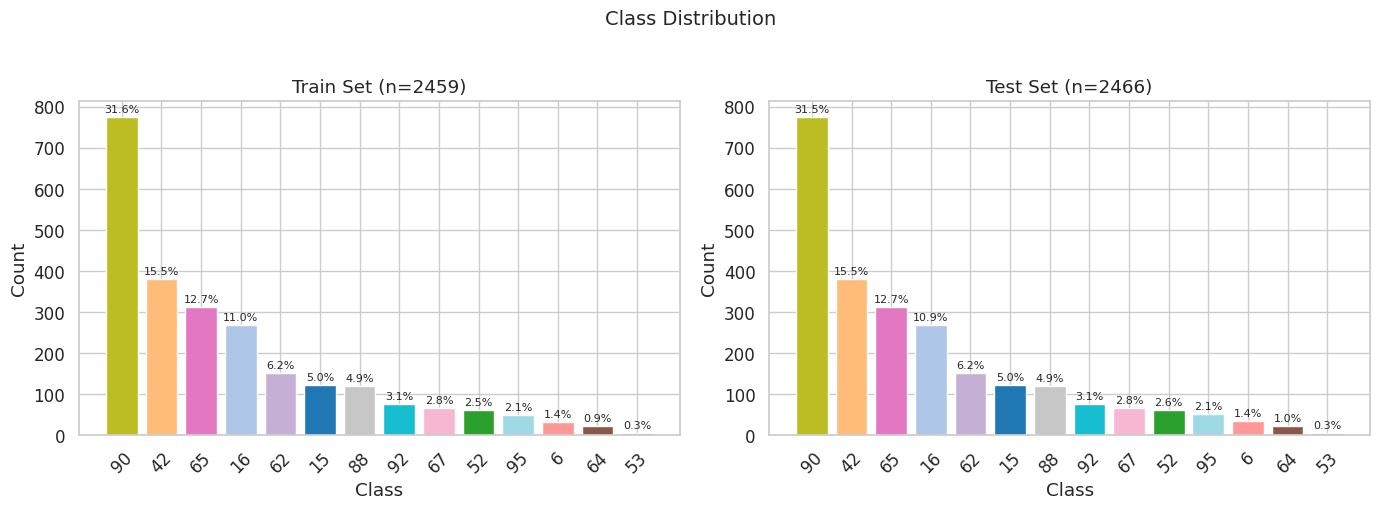

Imbalance ratio (max/min): 777/7 = 111:1


In [2]:
# Class distribution — train vs test side by side
train_counts = Counter(y_train)
test_counts = Counter(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in [(axes[0], train_counts, "Train"), (axes[1], test_counts, "Test")]:
    sorted_classes = sorted(counts.keys(), key=lambda c: counts[c], reverse=True)
    vals = [counts[c] for c in sorted_classes]
    total = sum(vals)
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    color_map = {c: colors[i] for i, c in enumerate(classes)}

    bars = ax.bar(range(len(sorted_classes)), vals,
                  color=[color_map[c] for c in sorted_classes])
    ax.set_xticks(range(len(sorted_classes)))
    ax.set_xticklabels(sorted_classes, rotation=45)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title(f"{title} Set (n={total})")

    # Add percentage labels
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{100*v/total:.1f}%", ha="center", va="bottom", fontsize=8)

plt.suptitle("Class Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Imbalance ratio
max_count = max(train_counts.values())
min_count = min(train_counts.values())
print(f"Imbalance ratio (max/min): {max_count}/{min_count} = {max_count/min_count:.0f}:1")

## 2. Per-Channel Statistics

The 6 channels correspond to LSST photometric bands (u, g, r, i, z, y).
Flux values span a wide range and increase in magnitude from u to y band.

In [3]:
# Per-channel summary statistics (train set)
print(f"{'Band':<6} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Median':>10}")
print("-" * 58)
for ch in range(6):
    vals = X_train_cf[:, ch, :]  # (n, T)
    print(f"{BAND_NAMES[ch]:<6} {vals.mean():>10.2f} {vals.std():>10.2f} "
          f"{vals.min():>10.2f} {vals.max():>10.2f} {np.median(vals):>10.2f}")

Band         Mean        Std        Min        Max     Median
----------------------------------------------------------
u            9.46     248.78   -3420.00   32932.00       0.27
g           18.97     780.92  -11585.00   44394.00       0.41
r           28.01     714.91  -10289.00   37032.00       0.65
i           38.97     846.07   -8009.90   48133.00       0.94
z           50.14    1116.89  -19855.00   60249.00       1.28
y           55.65    1427.11  -40036.00   64062.00       2.12


/tmp/ipykernel_28940/725621332.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=BAND_NAMES, showfliers=False, patch_artist=True)


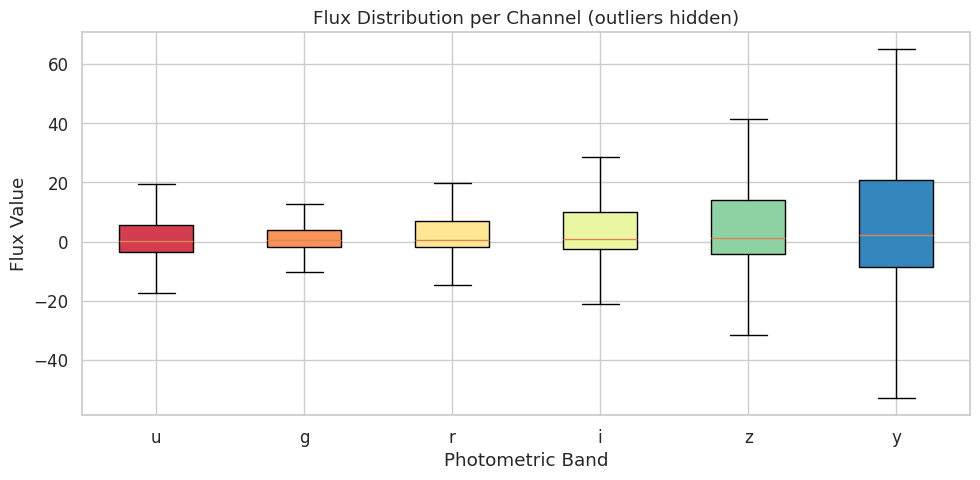

In [4]:
# Distribution of flux values per channel (boxplot)
fig, ax = plt.subplots(figsize=(10, 5))
data_for_box = [X_train_cf[:, ch, :].flatten() for ch in range(6)]
bp = ax.boxplot(data_for_box, labels=BAND_NAMES, showfliers=False, patch_artist=True)
colors = plt.cm.Spectral(np.linspace(0.1, 0.9, 6))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_xlabel("Photometric Band")
ax.set_ylabel("Flux Value")
ax.set_title("Flux Distribution per Channel (outliers hidden)")
plt.tight_layout()
plt.show()

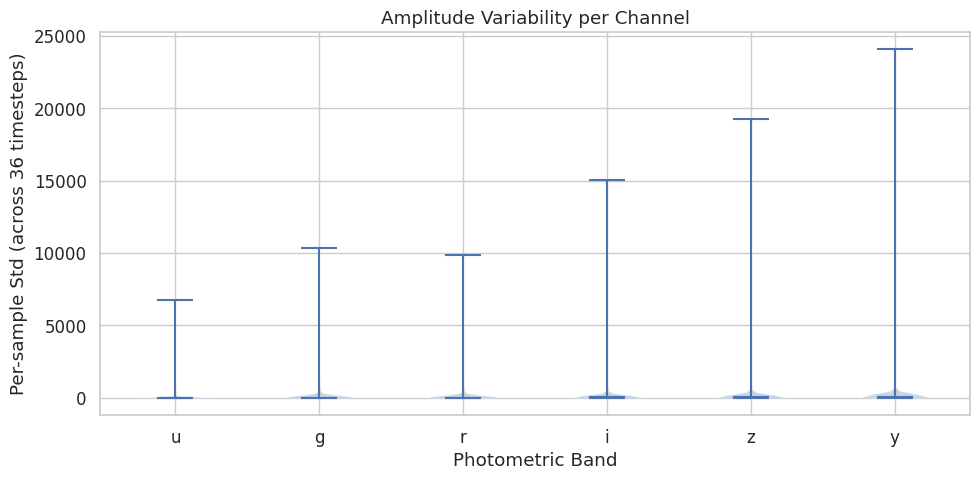

In [5]:
# Per-sample amplitude: standard deviation across time, per channel
# This shows how "active" each sample is in each band
sample_stds = X_train_cf.std(axis=2)  # (n, C)

fig, ax = plt.subplots(figsize=(10, 5))
ax.violinplot([sample_stds[:, ch] for ch in range(6)], positions=range(6), showmedians=True)
ax.set_xticks(range(6))
ax.set_xticklabels(BAND_NAMES)
ax.set_xlabel("Photometric Band")
ax.set_ylabel("Per-sample Std (across 36 timesteps)")
ax.set_title("Amplitude Variability per Channel")
plt.tight_layout()
plt.show()

## 3. Sample Light Curves per Class

Visualize a few random samples from each class to understand the diversity of light curve shapes.
Each subplot shows all 6 bands overlaid for one sample.

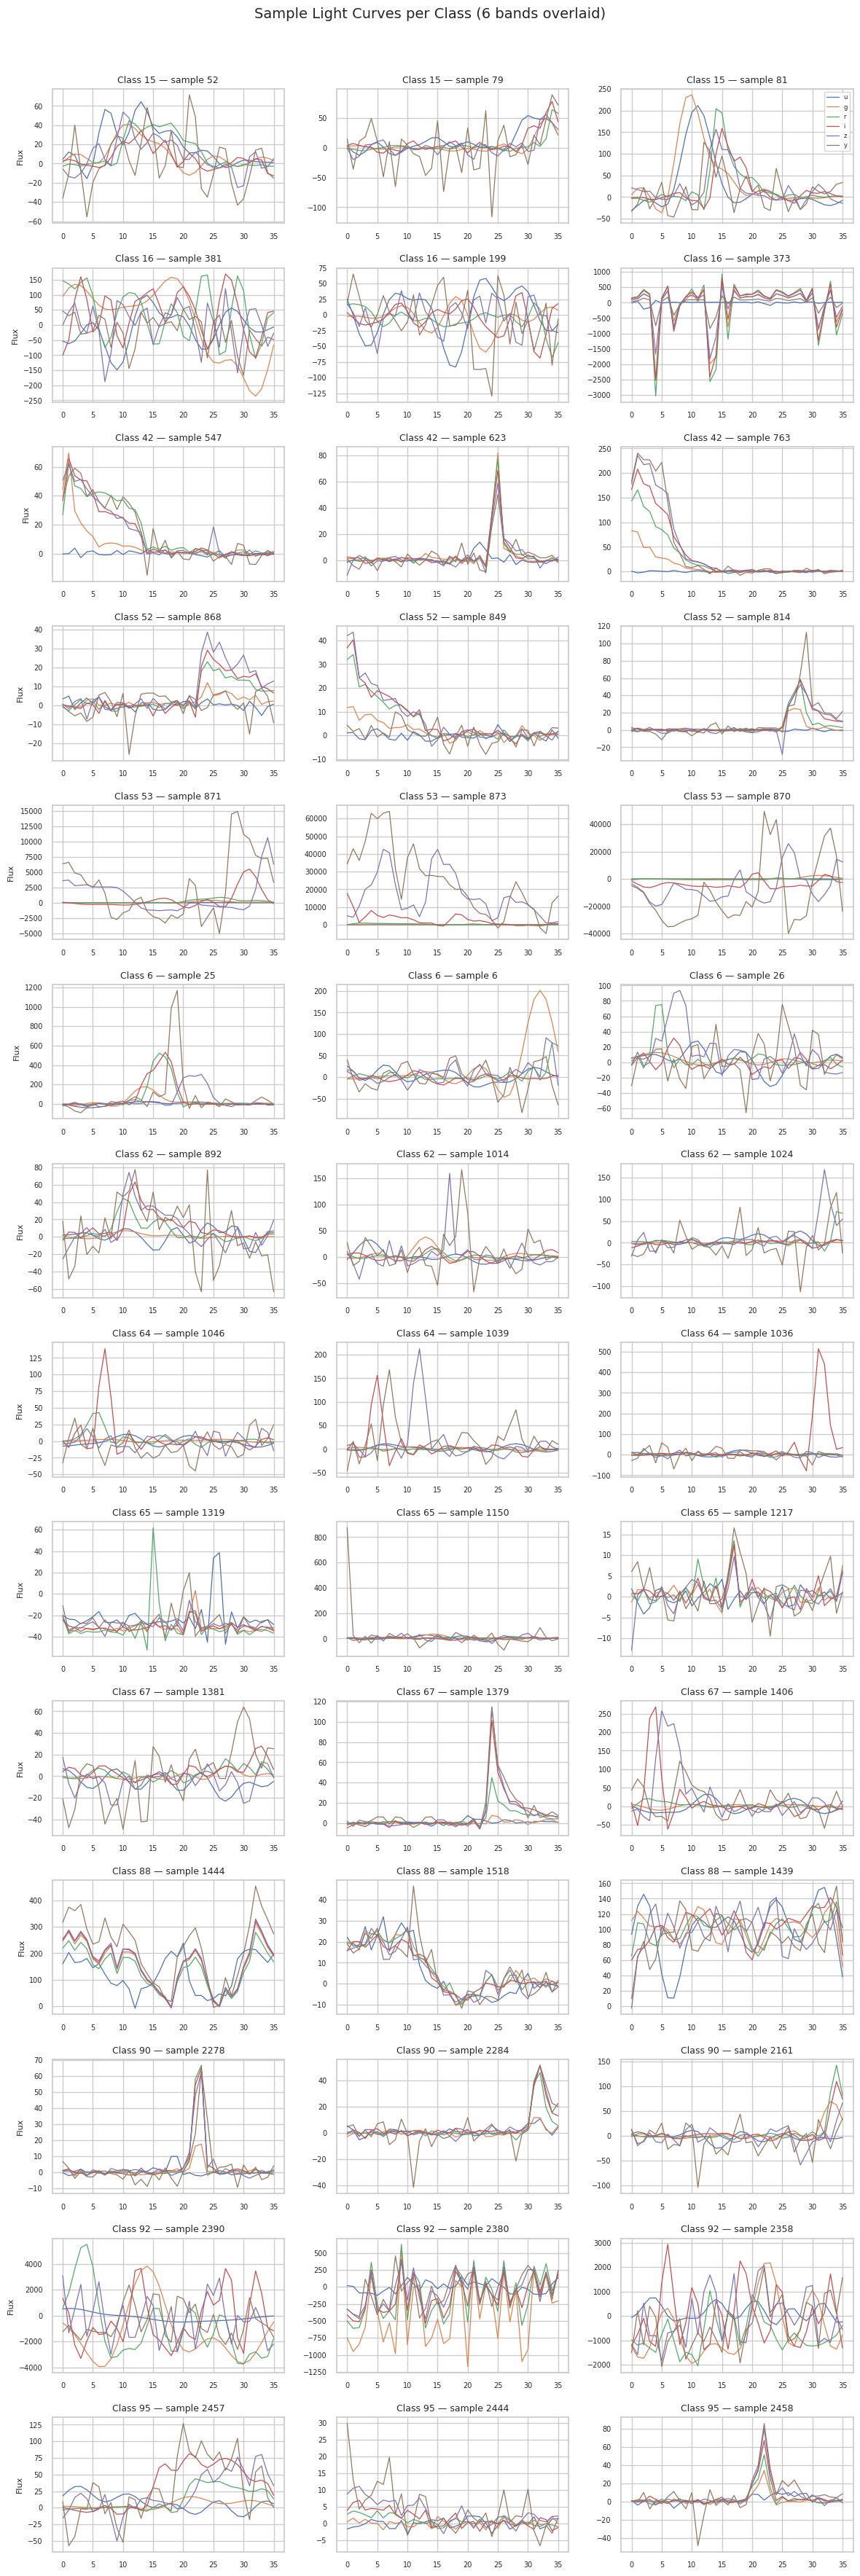

In [6]:
# 3 random samples per class, all 6 bands overlaid
rng = np.random.RandomState(SEED)
n_examples = 3

fig, axes = plt.subplots(n_classes, n_examples, figsize=(4 * n_examples, 2.5 * n_classes))

for row, cls in enumerate(classes):
    idxs = np.where(y_train == cls)[0]
    chosen = rng.choice(idxs, size=min(n_examples, len(idxs)), replace=False)

    for col, idx in enumerate(chosen):
        ax = axes[row, col]
        for ch in range(6):
            ax.plot(X_train_cf[idx, ch, :], label=BAND_NAMES[ch], linewidth=0.9)
        ax.set_title(f"Class {cls} — sample {idx}", fontsize=9)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel("Flux", fontsize=8)
        if row == 0 and col == n_examples - 1:
            ax.legend(fontsize=6, loc="upper right")

plt.suptitle("Sample Light Curves per Class (6 bands overlaid)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Mean Light Curve per Class

Average light curve shape for each class (with +/- 1 std shaded).
This reveals the "prototype" signature of each transient type.

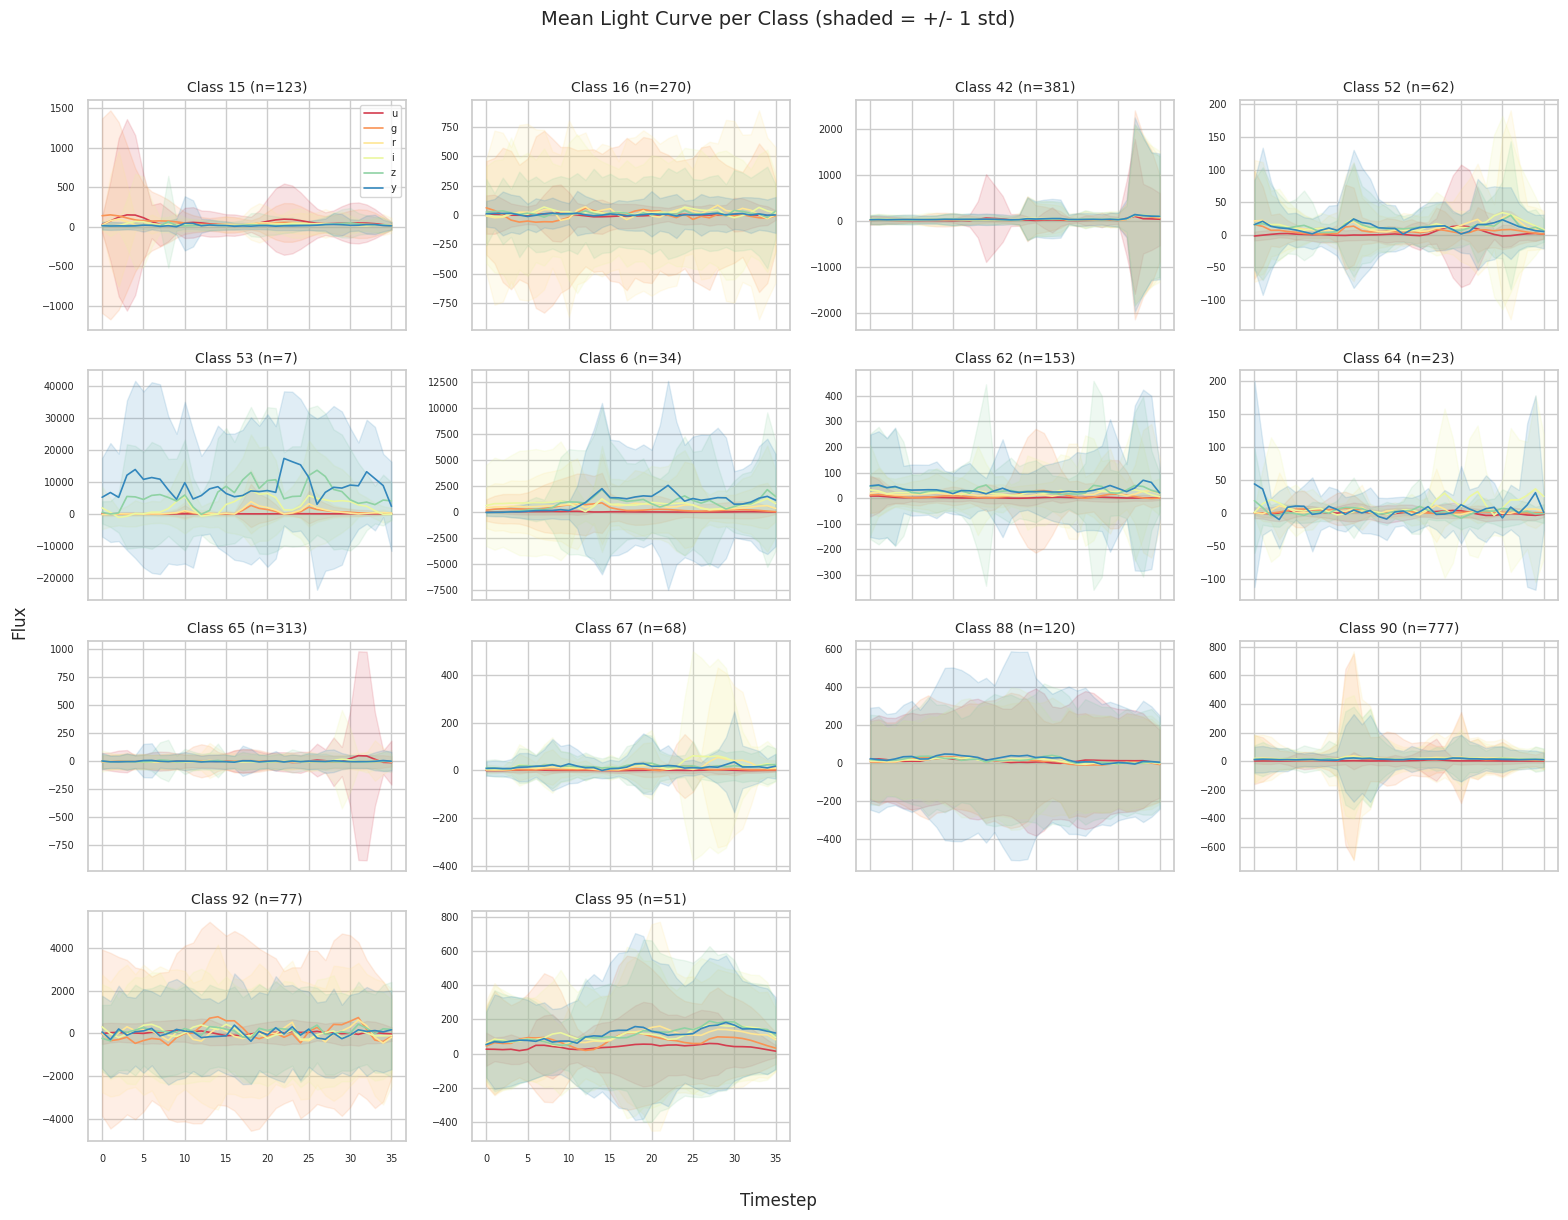

In [7]:
# Mean +/- std light curve per class (one subplot per class, bands overlaid)
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
axes = axes.flatten()
band_colors = plt.cm.Spectral(np.linspace(0.1, 0.9, 6))

for i, cls in enumerate(classes):
    ax = axes[i]
    mask = y_train == cls
    X_cls = X_train_cf[mask]  # (n_cls, C, T)

    for ch in range(6):
        mean_curve = X_cls[:, ch, :].mean(axis=0)
        std_curve = X_cls[:, ch, :].std(axis=0)
        t = np.arange(36)
        ax.plot(t, mean_curve, color=band_colors[ch], label=BAND_NAMES[ch], linewidth=1.2)
        ax.fill_between(t, mean_curve - std_curve, mean_curve + std_curve,
                        color=band_colors[ch], alpha=0.15)

    ax.set_title(f"Class {cls} (n={mask.sum()})", fontsize=10)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7, loc="upper right")
fig.supxlabel("Timestep", fontsize=12)
fig.supylabel("Flux", fontsize=12)
plt.suptitle("Mean Light Curve per Class (shaded = +/- 1 std)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Inter-Channel Correlation

How correlated are the 6 photometric bands? High correlation means channels carry
redundant information. Low correlation means each band adds unique signal.

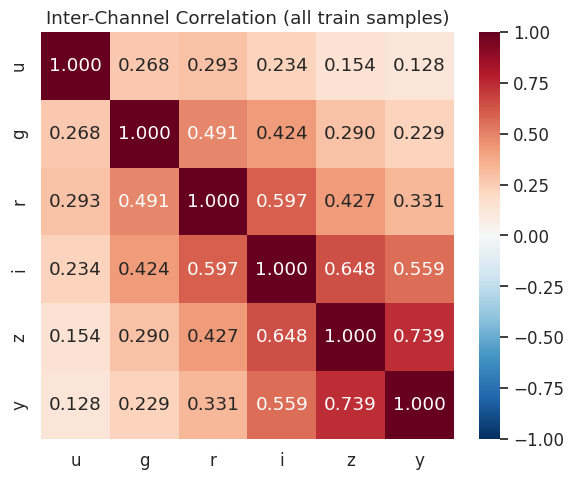

In [8]:
# Global inter-channel correlation (across all samples and timesteps)
# Reshape to (n*T, C) then compute correlation matrix
flat = X_train_cf.transpose(0, 2, 1).reshape(-1, 6)  # (n*T, C)
corr = np.corrcoef(flat.T)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", xticklabels=BAND_NAMES,
            yticklabels=BAND_NAMES, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Inter-Channel Correlation (all train samples)")
plt.tight_layout()
plt.show()

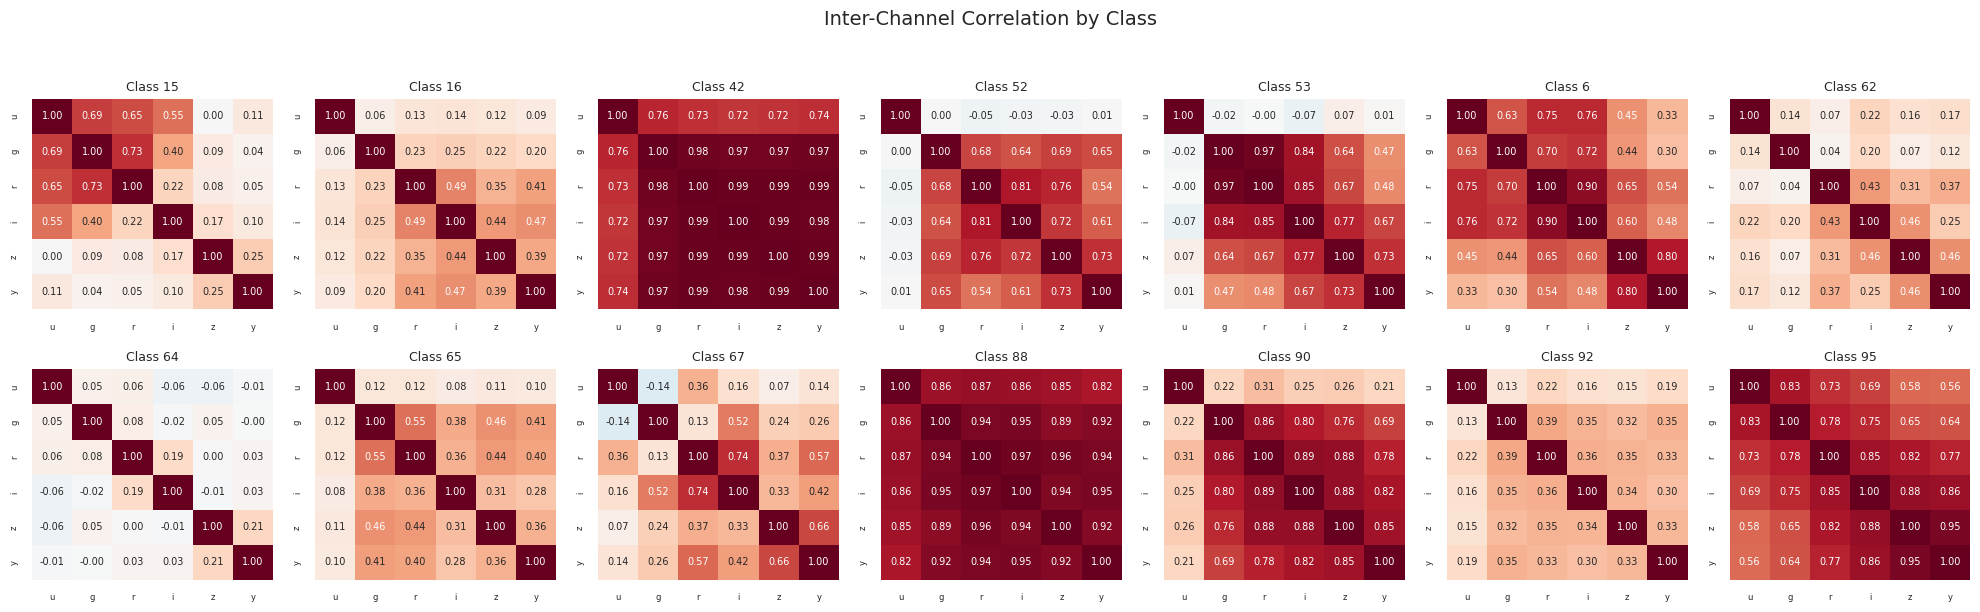

In [9]:
# Per-class channel correlation — does correlation structure vary by class?
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    mask = y_train == cls
    flat_cls = X_train_cf[mask].transpose(0, 2, 1).reshape(-1, 6)
    corr_cls = np.corrcoef(flat_cls.T)
    sns.heatmap(corr_cls, annot=True, fmt=".2f", xticklabels=BAND_NAMES,
                yticklabels=BAND_NAMES, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=axes[i], cbar=False, annot_kws={"size": 7})
    axes[i].set_title(f"Class {cls}", fontsize=9)
    axes[i].tick_params(labelsize=6)

plt.suptitle("Inter-Channel Correlation by Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Per-Class Amplitude Distribution

Amplitude (per-sample std across time) is a key discriminative feature for
astronomical transients. Some classes are bright/high-amplitude, others are faint.
This is why MOMENT's RevIN normalization is problematic — it erases this signal.

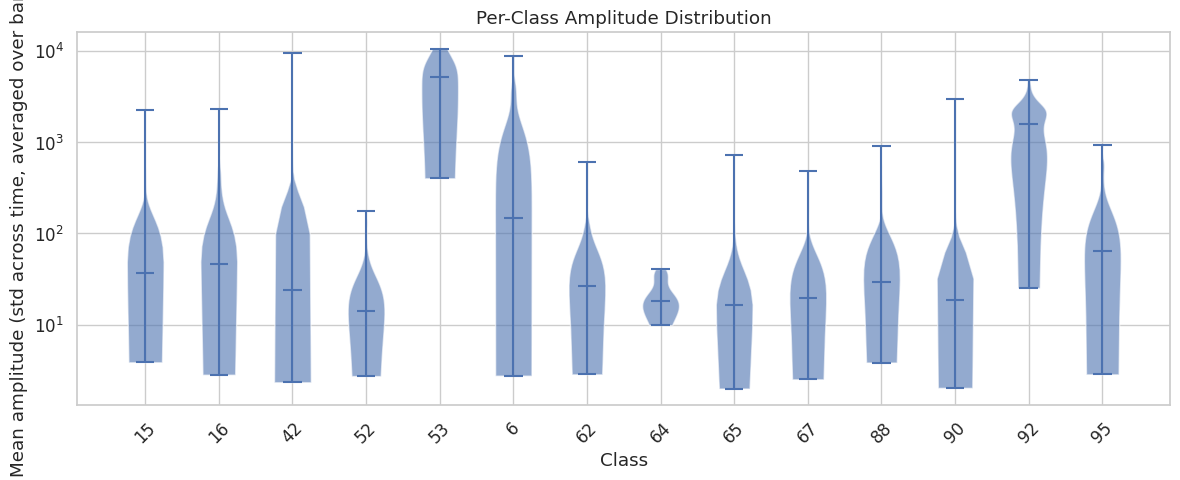

In [10]:
# Per-sample total amplitude: mean std across all 6 channels
total_amplitude = X_train_cf.std(axis=2).mean(axis=1)  # (n,)

fig, ax = plt.subplots(figsize=(12, 5))
class_amplitudes = []
positions = []
for i, cls in enumerate(classes):
    mask = y_train == cls
    class_amplitudes.append(total_amplitude[mask])
    positions.append(i)

parts = ax.violinplot(class_amplitudes, positions=positions, showmedians=True)
for pc in parts["bodies"]:
    pc.set_alpha(0.6)

ax.set_xticks(positions)
ax.set_xticklabels(classes, rotation=45)
ax.set_xlabel("Class")
ax.set_ylabel("Mean amplitude (std across time, averaged over bands)")
ax.set_title("Per-Class Amplitude Distribution")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 7. Temporal Patterns: Autocorrelation

Autocorrelation at different lags reveals whether light curves have smooth trends
(high autocorrelation) or are noisy/spiky (low autocorrelation).
This informs the choice of model architecture — smooth signals favor longer kernels.

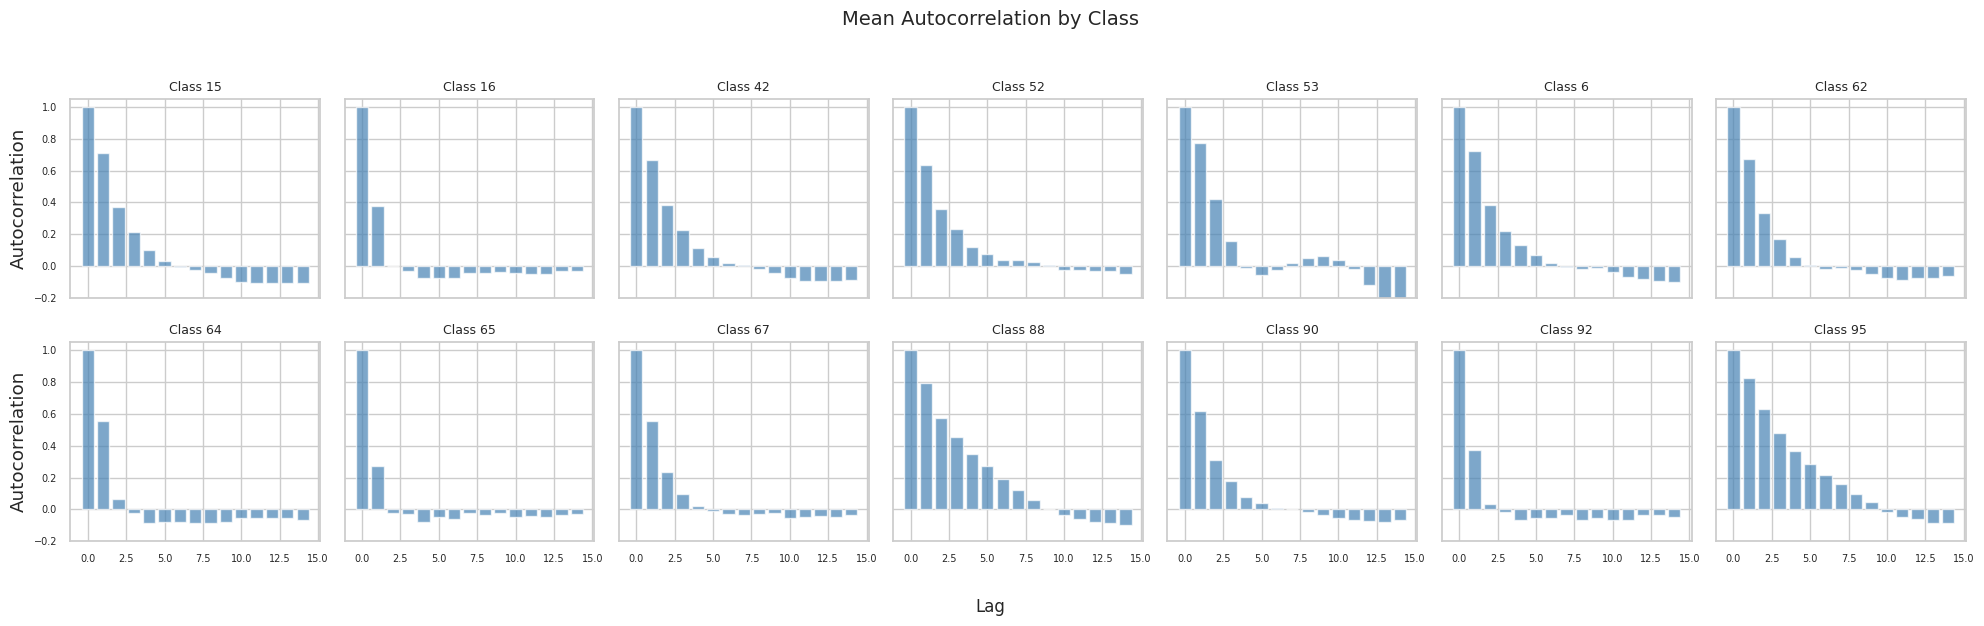

In [11]:
# Mean autocorrelation per class (averaged over channels and samples)
max_lag = 15

fig, axes = plt.subplots(2, 7, figsize=(20, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, cls in enumerate(classes):
    mask = y_train == cls
    X_cls = X_train_cf[mask]  # (n_cls, C, T)
    n_cls = X_cls.shape[0]

    mean_acf = np.zeros(max_lag)
    for lag in range(max_lag):
        # Correlation between t and t+lag, averaged over all channels and samples
        x1 = X_cls[:, :, :36 - lag]
        x2 = X_cls[:, :, lag:]
        # Pearson correlation per sample per channel, then average
        corrs = []
        for s in range(n_cls):
            for ch in range(6):
                c = np.corrcoef(x1[s, ch], x2[s, ch])[0, 1]
                if not np.isnan(c):
                    corrs.append(c)
        mean_acf[lag] = np.mean(corrs) if corrs else 0

    axes[i].bar(range(max_lag), mean_acf, color="steelblue", alpha=0.7)
    axes[i].set_title(f"Class {cls}", fontsize=9)
    axes[i].set_ylim(-0.2, 1.05)
    axes[i].tick_params(labelsize=7)
    if i % 7 == 0:
        axes[i].set_ylabel("Autocorrelation")

fig.supxlabel("Lag", fontsize=12)
plt.suptitle("Mean Autocorrelation by Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature-Space Separability (PCA)

Project the raw flattened time series into 2D via PCA to see if classes form
distinguishable clusters in the raw feature space (without any learned representation).

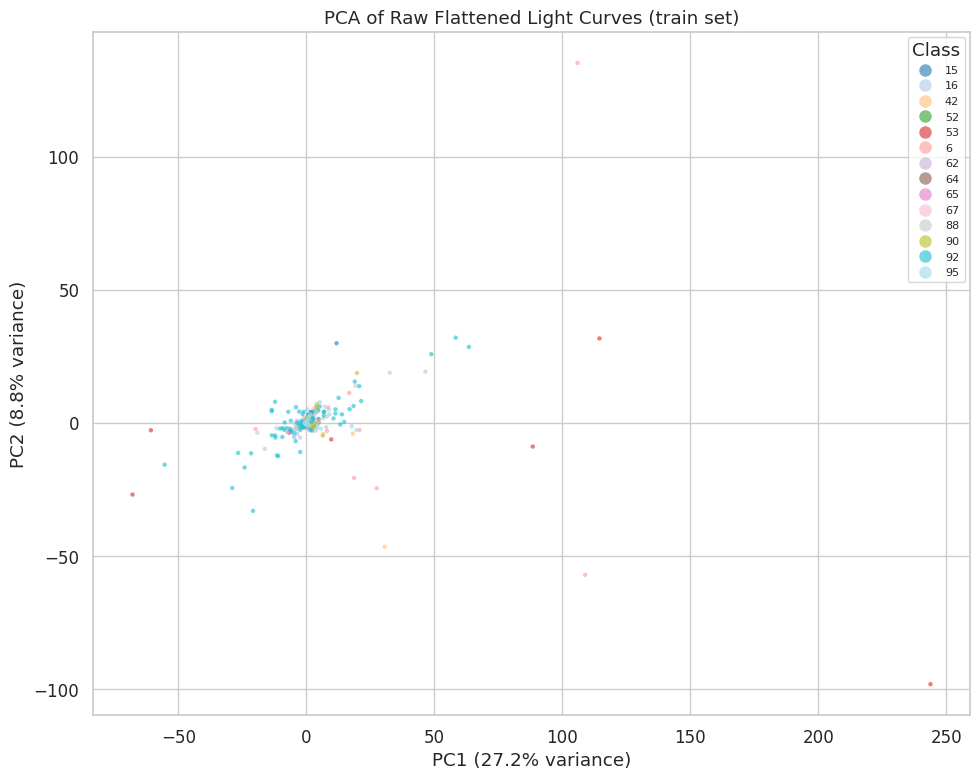

Explained variance by first 2 PCs: 36.0%


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Flatten: (n, C, T) -> (n, C*T)
X_flat = X_train_cf.reshape(X_train_cf.shape[0], -1)
X_scaled = StandardScaler().fit_transform(X_flat)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_enc, cmap="tab20",
                s=10, alpha=0.6, linewidths=0)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of Raw Flattened Light Curves (train set)")

handles, _ = sc.legend_elements()
ax.legend(handles, list(classes), title="Class", fontsize=8, markerscale=1.5,
          loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

print(f"Explained variance by first 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

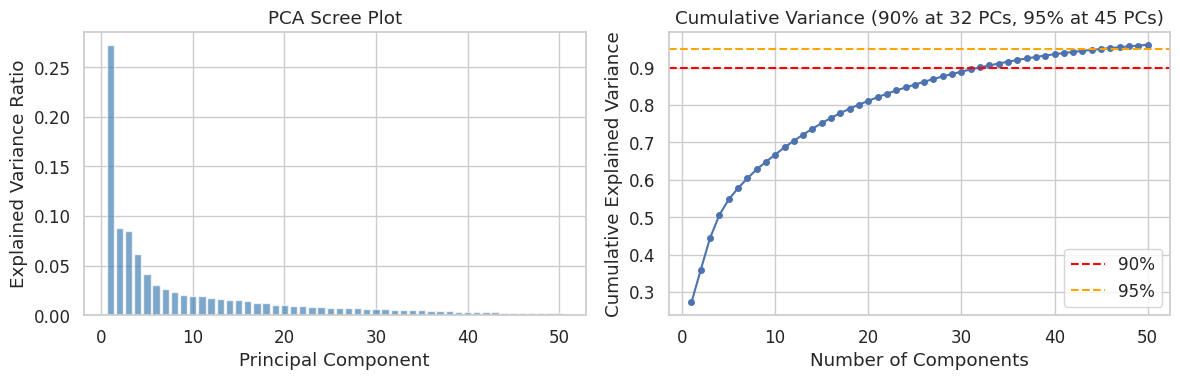

In [13]:
# PCA scree plot — how many components capture meaningful variance?
pca_full = PCA(n_components=min(50, X_flat.shape[1]))
pca_full.fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color="steelblue", alpha=0.7)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA Scree Plot")

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, len(cumvar) + 1), cumvar, "o-", markersize=4)
ax2.axhline(y=0.90, color="red", linestyle="--", label="90%")
ax2.axhline(y=0.95, color="orange", linestyle="--", label="95%")
n90 = np.searchsorted(cumvar, 0.90) + 1
n95 = np.searchsorted(cumvar, 0.95) + 1
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title(f"Cumulative Variance (90% at {n90} PCs, 95% at {n95} PCs)")
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Band-wise Class Separability

For each band, compute the mean flux per sample and visualize the distribution per class.
This shows which bands are most discriminative for separating transient types.

/tmp/ipykernel_28940/3438411727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/3438411727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/3438411727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/3438411727.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been r

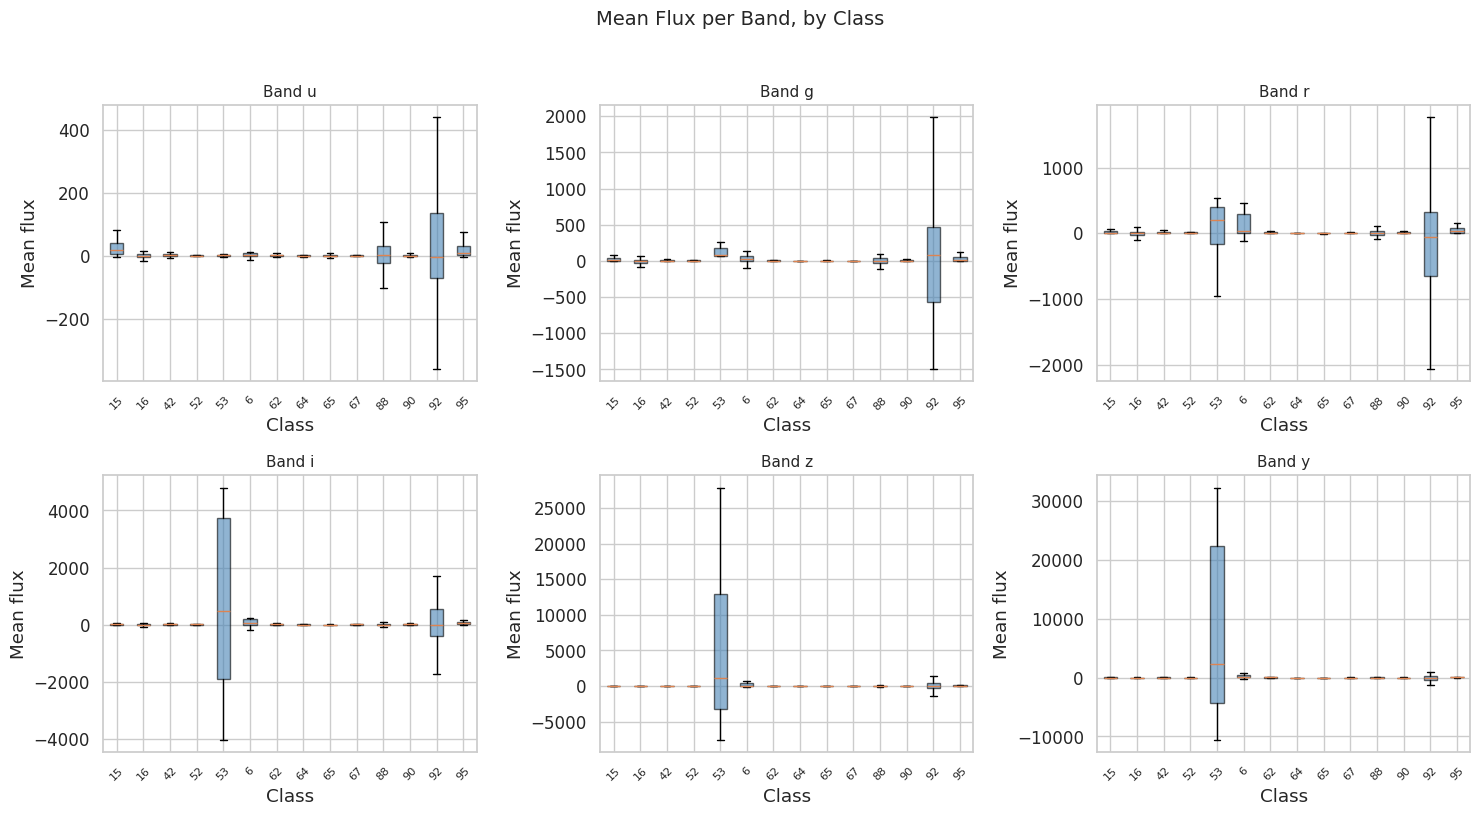

In [14]:
# Mean flux per sample per band, grouped by class
mean_flux = X_train_cf.mean(axis=2)  # (n, C)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()

for ch in range(6):
    ax = axes[ch]
    data_per_class = [mean_flux[y_train == cls, ch] for cls in classes]
    bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.6)
    ax.set_title(f"Band {BAND_NAMES[ch]}", fontsize=11)
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean flux")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("Mean Flux per Band, by Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Color Ratios (Band Ratios)

In astronomy, "color" is the flux ratio between adjacent bands. These ratios encode
the spectral energy distribution of a transient and are strongly class-discriminative.

/tmp/ipykernel_28940/997012522.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/997012522.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/997012522.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
/tmp/ipykernel_28940/997012522.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

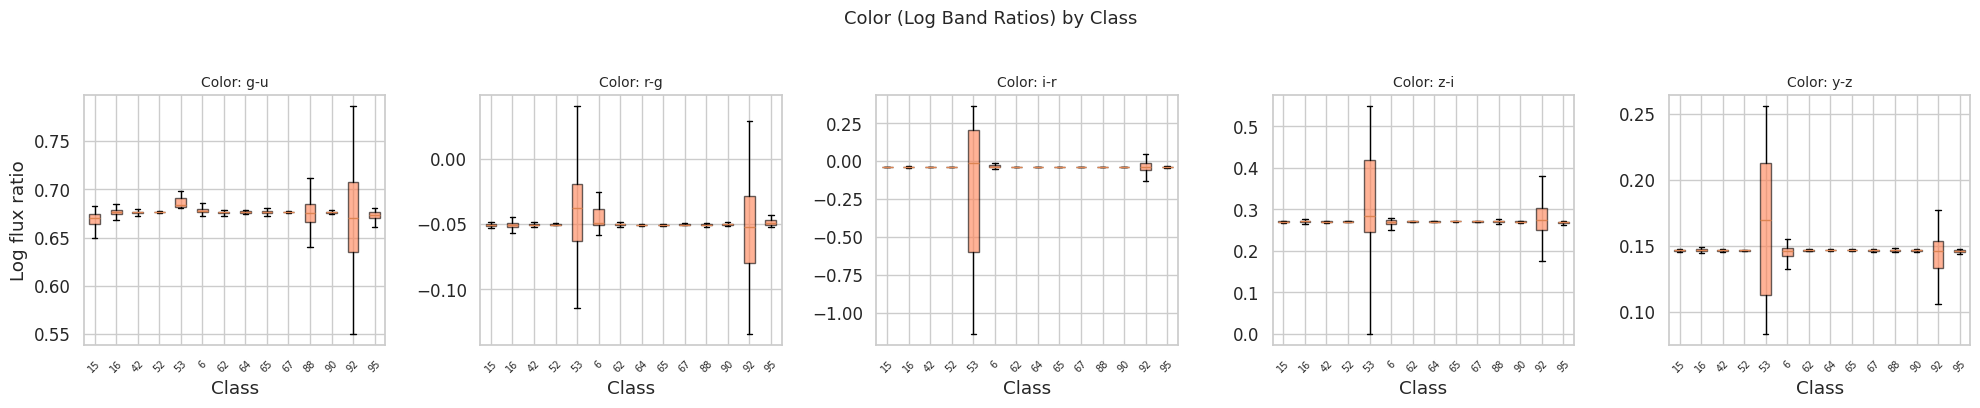

In [15]:
# Compute mean flux per band per sample, then log-ratio of adjacent bands
mean_flux = X_train_cf.mean(axis=2)  # (n, 6)
# Avoid log of negative/zero by shifting to positive range
shifted = mean_flux - mean_flux.min(axis=0, keepdims=True) + 1.0  # all positive
log_flux = np.log10(shifted)

# Adjacent band ratios (colors): g-u, r-g, i-r, z-i, y-z
color_names = ["g-u", "r-g", "i-r", "z-i", "y-z"]
colors_arr = np.diff(log_flux, axis=1)  # (n, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
for j in range(5):
    ax = axes[j]
    data_per_class = [colors_arr[y_train == cls, j] for cls in classes]
    bp = ax.boxplot(data_per_class, labels=classes, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("coral")
        patch.set_alpha(0.6)
    ax.set_title(f"Color: {color_names[j]}", fontsize=10)
    ax.set_xlabel("Class")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    if j == 0:
        ax.set_ylabel("Log flux ratio")

plt.suptitle("Color (Log Band Ratios) by Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary Statistics Table

In [16]:
# Summary table: per-class stats
print(f"{'Class':<8} {'N_train':>8} {'N_test':>8} {'%_train':>8} {'Mean_amp':>10} {'Median_amp':>11}")
print("-" * 58)

train_counts = Counter(y_train)
test_counts = Counter(y_test)
total_amplitude = X_train_cf.std(axis=2).mean(axis=1)

for cls in classes:
    n_tr = train_counts[cls]
    n_te = test_counts[cls]
    pct = 100 * n_tr / len(y_train)
    mask = y_train == cls
    amp = total_amplitude[mask]
    print(f"{cls:<8} {n_tr:>8} {n_te:>8} {pct:>7.1f}% {amp.mean():>10.2f} {np.median(amp):>11.2f}")

print(f"\n{'Total':<8} {len(y_train):>8} {len(y_test):>8}")
print(f"\nKey observations:")
print(f"  - 14 classes, heavily imbalanced (111:1 ratio)")
print(f"  - 6 channels (photometric bands), 36 timesteps")
print(f"  - No missing values (NaN)")
print(f"  - Amplitude is class-discriminative (orders of magnitude difference)")
print(f"  - Adjacent bands are correlated but correlation structure varies by class")

Class     N_train   N_test  %_train   Mean_amp  Median_amp
----------------------------------------------------------
15            123      124     5.0%      79.07       36.76
16            270      270    11.0%     142.27       45.57
42            381      382    15.5%      77.13       24.11
52             62       63     2.5%      24.81       13.93
53              7        7     0.3%    4487.59     5188.25
6              34       35     1.4%    1068.14      147.35
62            153      153     6.2%      52.08       26.17
64             23       24     0.9%      21.61       18.03
65            313      313    12.7%      27.50       16.40
67             68       68     2.8%      33.69       19.33
88            120      121     4.9%      60.69       29.31
90            777      777    31.6%      38.15       18.78
92             77       77     3.1%    1571.48     1584.72
95             51       52     2.1%     129.28       63.38

Total        2459     2466

Key observations:
  - 14 cl